# INVERTER CIRCUIT 7nm FINFET

> Path: /home/eduarda/Repos/Electrical-Behaviour-Prediction/FINFET/7nm/NOT/Data/sim1/simResults_NOTfet/all_results_inverter.csv

> https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction/tree/main/FINFET

# Data exploration
Outliers were already removed in 01_data_cleaning

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
dataset_path = "/home/eduarda/Repos/jupyter_ic/data/processed/FINFET/7nm/NOT/01_data_cleaning/finfet_df.csv"
plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/FINFET/7nm/NOT/02_data_exploration_plots"
data = pd.read_csv(dataset_path, index_col=0)

# Dataset

Inputs (6 total)
x = [nmos@fet, pmos@fet, temperature, voltage, finsNumber, capacitance]

Outputs (3 total)
y = [tphl, tplh, energy]

Variables (9 total)

- **nmos@fet**: NMOS transistor process variation parameter for the FinFET device
- **pmos@fet**: PMOS transistor process variation parameter for the FinFET device
- **tphl**: propagation delay from output High to Low
- **tplh**: propagation delay from output Low to High
- **energy**: energy dissipated by the circuit
- **voltage**: supply voltage (VDD)
- **capacitance**:  load capacitance at the inverter output
- **finsNumber** number of fins in the FinFET transistor structure
- **temperature**: operating temperature of the circuit

Units
- **nfet@var (PV_nfet)**: Electron-volt (eV)
- **pfet@var (PV_pfet)**: Electron-volt (eV)
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **energy**: Joules (J)
- **voltage**: Volts (V)
- **capacitance**: Farads (F)
- **finsNumber**: unitless
- **temperature**: Celsius (°C)

There aren't fixed variables values

- **nfet@var (PV_nfet)**: 100 different values
- **pfet@var (PV_pfet)**: 100 different values
- **tphl**: 35.369 different values
- **tplh**: 35.463 different values
- **energy**: 44.144 different values
- **voltage**: 4 different values (0.6, 0.7, 0.8, 0.9)
- **capacitance**: 4 different values (1, 4, 8, 16)
- **finsNumber**: 5 different values (1, 2, 3, 4, 5)
- **temperature**: 6 different values (-25, 0, 25, 50, 75, 100)

In [21]:
data

,PV_nfet,PV_pfet,temperature,voltage,capacitance,finsNumber,tphl,tplh,energy
0,4.370067,4.852864,-25,0.6,1,1,1.230100e-11,1.582600e-11,-6.400970e-16
1,4.370806,4.873612,-25,0.6,1,1,1.232850e-11,1.470250e-11,-6.432540e-16
2,4.333499,4.850897,-25,0.6,1,1,1.128970e-11,1.594150e-11,-6.402650e-16
3,4.407237,4.856645,-25,0.6,1,1,1.353270e-11,1.560170e-11,-6.396860e-16
4,4.387795,4.770993,-25,0.6,1,1,1.282430e-11,2.289280e-11,-6.353580e-16
...,...,...,...,...,...,...,...,...,...
17787,4.394857,4.742083,50,0.7,4,5,1.191030e-11,1.653320e-11,-2.999310e-15
17812,4.422562,4.731136,75,0.7,4,5,1.300710e-11,1.734630e-11,-2.996600e-15
17824,4.496100,4.726905,75,0.7,4,5,1.669720e-11,1.759530e-11,-2.992060e-15
17867,4.415865,4.790164,75,0.7,4,5,1.276600e-11,1.438970e-11,-2.995500e-15


In [22]:
data.info()

<class 'pandas.DataFrame'>
Index: 14215 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PV_nfet      14215 non-null  float64
 1   PV_pfet      14215 non-null  float64
 2   temperature  14215 non-null  int64  
 3   voltage      14215 non-null  float64
 4   capacitance  14215 non-null  int64  
 5   finsNumber   14215 non-null  int64  
 6   tphl         14215 non-null  float64
 7   tplh         14215 non-null  float64
 8   energy       14215 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 1.1 MB


In [23]:
data["voltage"].value_counts()

voltage
0.6    5382
0.7    4579
0.8    2823
0.9    1431
Name: count, dtype: int64

In [24]:
data["capacitance"].value_counts()

capacitance
1    10253
4     3962
Name: count, dtype: int64

In [25]:
#why there's only two values of capacitance?? outliers?

In [26]:
data["finsNumber"].value_counts()

finsNumber
2    3240
3    3137
4    2970
5    2670
1    2198
Name: count, dtype: int64

In [27]:
data["temperature"].value_counts()

temperature
-25     2651
 0      2564
 25     2452
 50     2347
 75     2186
 100    2015
Name: count, dtype: int64

In [28]:
data.nunique()

PV_nfet          100
PV_pfet          100
temperature        6
voltage            4
capacitance        2
finsNumber         5
tphl           13060
tplh           13097
energy         13770
dtype: int64

In [29]:
data.describe(include="all")

,PV_nfet,PV_pfet,temperature,voltage,capacitance,finsNumber,tphl,tplh,energy
count,14215.000000,14215.000000,14215.000000,14215.000000,14215.000000,14215.000000,1.421500e+04,1.421500e+04,1.421500e+04
mean,4.372756,4.812947,33.614140,0.702132,1.836159,3.047415,1.026585e-11,1.310709e-11,-1.479726e-15
std,0.041589,0.047915,42.307052,0.098969,1.345155,1.343340,5.267481e-12,8.323003e-12,8.543752e-16
min,4.281295,4.706879,-25.000000,0.600000,1.000000,1.000000,3.254290e-12,3.525430e-12,-2.999910e-15
25%,4.340033,4.780044,0.000000,0.600000,1.000000,2.000000,5.954280e-12,6.760065e-12,-2.511035e-15
50%,4.374819,4.812732,25.000000,0.700000,1.000000,3.000000,8.379490e-12,9.882380e-12,-9.863540e-16
75%,4.400307,4.849204,75.000000,0.800000,4.000000,4.000000,1.353270e-11,1.695420e-11,-7.839550e-16
max,4.496100,4.944579,100.000000,0.900000,4.000000,5.000000,2.875000e-11,6.473860e-11,-5.803990e-16


In [30]:
data.shape

(14215, 9)

In [31]:
output_vars = ['tphl', 'tplh', 'energy']

variance_results = data[output_vars].var()
std_dev_results = data[output_vars].std()

eda_summary = pd.DataFrame({
    'Variance': variance_results,
    'Standard Deviation': std_dev_results
})

print(eda_summary)

            Variance  Standard Deviation
tphl    2.774635e-23        5.267481e-12
tplh    6.927238e-23        8.323003e-12
energy  7.299569e-31        8.543752e-16


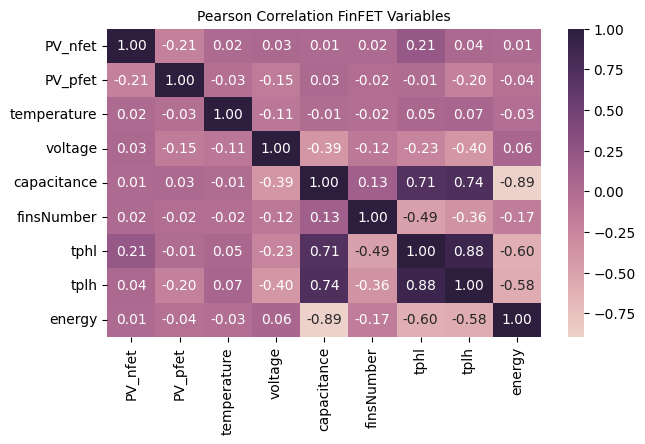

In [32]:
# Correlation
plt.figure(figsize=(7, 4))
ax = sns.heatmap(data.corr(method='pearson', numeric_only=True), annot=True, fmt=".2f", cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Pearson Correlation FinFET Variables', fontsize=10)
ax=ax
plt.savefig(f"{plots_dir}/finfet_correlation.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [33]:
data.corr()

,PV_nfet,PV_pfet,temperature,voltage,capacitance,finsNumber,tphl,tplh,energy
PV_nfet,1.000000,-0.207693,0.018656,0.032028,0.010056,0.017613,0.212025,0.036551,0.010989
PV_pfet,-0.207693,1.000000,-0.033813,-0.152529,0.025885,-0.016475,-0.008306,-0.202353,-0.043744
temperature,0.018656,-0.033813,1.000000,-0.109190,-0.010400,-0.024115,0.047504,0.067909,-0.027792
voltage,0.032028,-0.152529,-0.109190,1.000000,-0.391025,-0.123528,-0.230400,-0.396482,0.058529
capacitance,0.010056,0.025885,-0.010400,-0.391025,1.000000,0.130367,0.709723,0.739469,-0.893484
finsNumber,0.017613,-0.016475,-0.024115,-0.123528,0.130367,1.000000,-0.485010,-0.364078,-0.166399
tphl,0.212025,-0.008306,0.047504,-0.230400,0.709723,-0.485010,1.000000,0.878794,-0.603581
tplh,0.036551,-0.202353,0.067909,-0.396482,0.739469,-0.364078,0.878794,1.000000,-0.583471
energy,0.010989,-0.043744,-0.027792,0.058529,-0.893484,-0.166399,-0.603581,-0.583471,1.000000


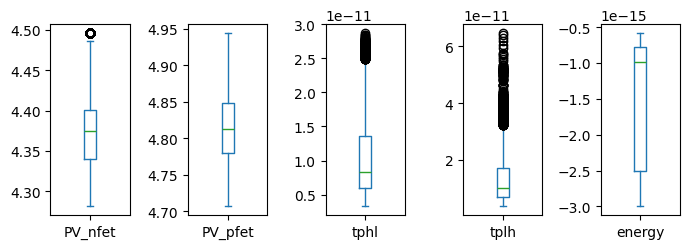

In [34]:
#Boxplot
variables = ['capacitance', 'voltage', 'finsNumber', 'temperature']
cols = [c for c in data.columns if 'length' not in c.lower() and c not in variables]
axes = data[cols].plot(kind='box', figsize=(7, 2.6), subplots=True, layout=(1, len(cols)))

plt.tight_layout()
plt.savefig(f"{plots_dir}/finfet_boxplot.png", bbox_inches='tight')
plt.show()
plt.close()

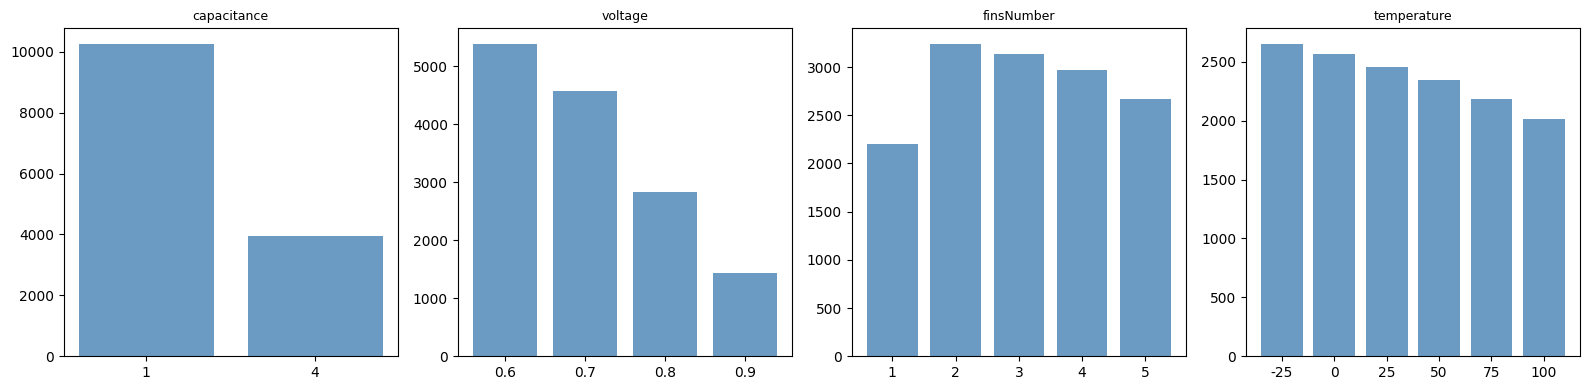

In [35]:
cols = ['capacitance', 'voltage', 'finsNumber', 'temperature']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cols):
    counts = data[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig(f"{plots_dir}/finfet_count_plot.png")
plt.show()
plt.close()

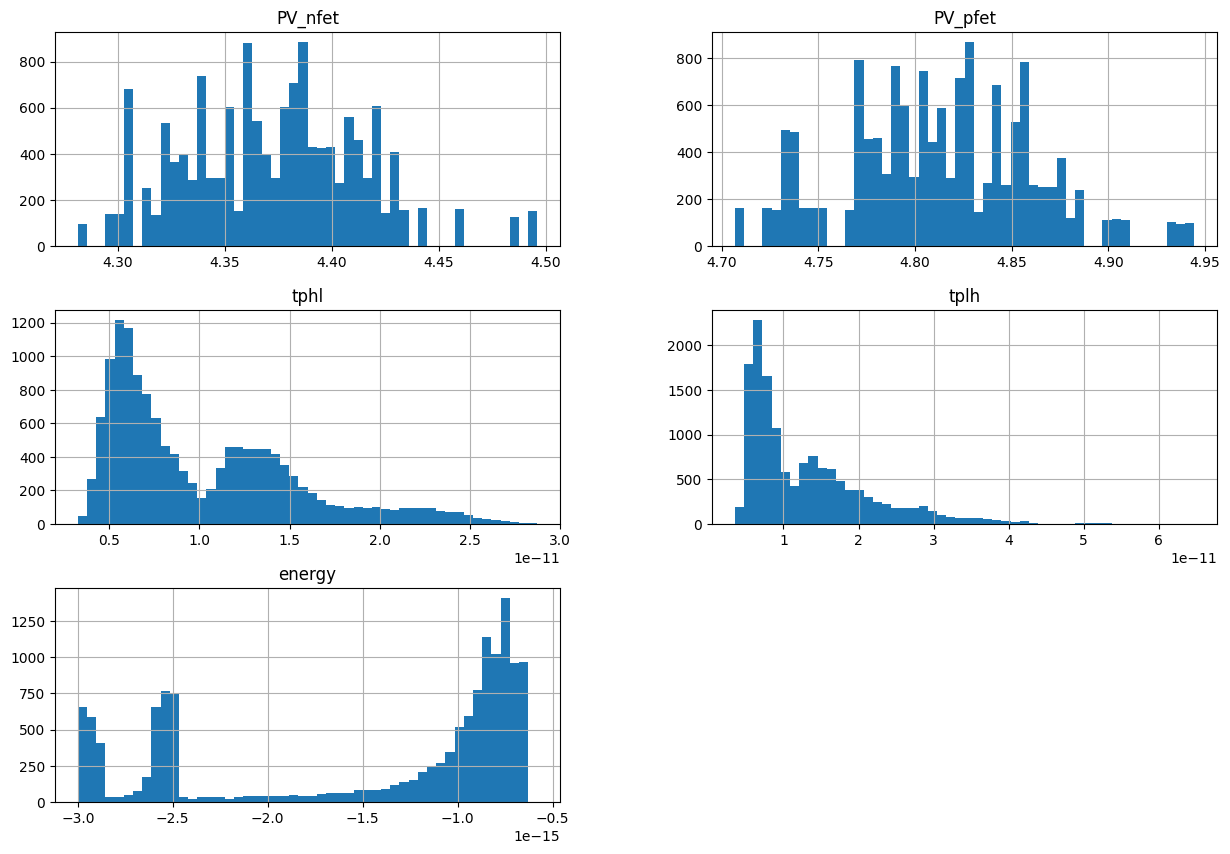

In [36]:
data[['PV_nfet', 'PV_pfet', 'tphl', 'tplh', 'energy']].hist(
    bins=50, 
    figsize=(15, 10), 
    layout=(3, 2)
)

plt.savefig(f"{plots_dir}/finfet_histogram.png")
plt.show()
plt.close()

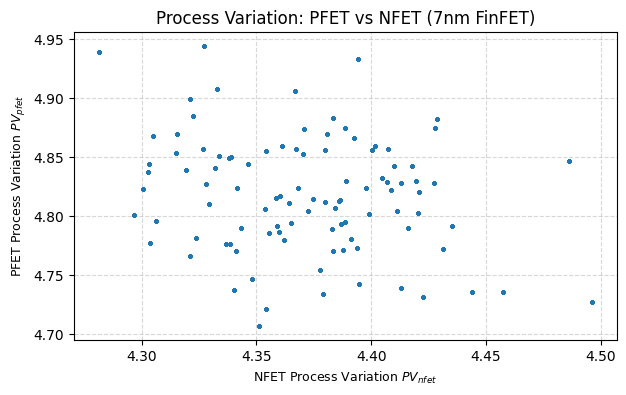

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
plt.plot('PV_nfet', 'PV_pfet', data=data, linestyle='none', marker='D', markersize=2)
plt.title('Process Variation: PFET vs NFET (7nm FinFET)')
plt.xlabel('NFET Process Variation $PV_{nfet}$', fontsize=9)
plt.ylabel('PFET Process Variation $PV_{pfet}$', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig(f"{plots_dir}/finfet_scatter_plot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [38]:
data.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/FINFET/7nm/NOT/02_data_exploration/finfet_df.csv', index=True)